# Breast Cancer Detection (BreaKHis 400x)

## Env set up

In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# For radiomics features
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.exposure import rescale_intensity

## Random Seed Setup

In [35]:
import random

# 设置随机种子为666，确保结果可复现
SEED = 666

# Python随机种子
random.seed(SEED)

# NumPy随机种子
np.random.seed(SEED)

# PyTorch随机种子
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # 如果使用多GPU

# 设置PyTorch的确定性模式（可能会降低性能，但保证可复现）
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 设置Python的hash随机化（可选，用于某些库的确定性）
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✅ Random seed set to {SEED} for reproducibility")

✅ Random seed set to 666 for reproducibility


## Device setup

In [36]:
device = (
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Data loading and preprocessing

In [37]:
class BreastCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths = []
        self.labels = []
        self.classes = [
            c for c in sorted(os.listdir(root_dir))
            if os.path.isdir(os.path.join(root_dir, c)) and not c.startswith('.')
        ]
        for i, c in enumerate(self.classes):
            imgs = glob(os.path.join(root_dir, c, "*.png"))
            self.img_paths.extend(imgs)
            self.labels.extend([i]*len(imgs))
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

## Radiomics Feature Extraction
def safe_read_rgb(path):
    """安全读取RGB图像"""
    img = cv2.imread(path)
    if img is None: 
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def safe_listdir(path):
    """列出目录中的所有有效文件，排除掉 .DS_Store 和非图片文件"""
    return [
        f for f in os.listdir(path)
        if not f.startswith('.') and f.lower() != "ds_store" and f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

def extract_radiomics_features(img_rgb):
    """
    提取影像组学特征
    包括：颜色统计、一阶统计、GLCM纹理特征、LBP特征
    返回39维特征向量
    """
    feats = {}
    # Resize for consistency (keeps enough detail for stats)
    H, W = 256, 256
    img = cv2.resize(img_rgb, (W, H), interpolation=cv2.INTER_AREA)

    # Color stats (RGB + HSV)
    img_hsv = (rgb2hsv(img / 255.0) * 255.0).astype(np.uint8)
    for space_name, arr in [("rgb", img), ("hsv", img_hsv)]:
        for c, cname in enumerate(["c1","c2","c3"]):
            ch = arr[..., c].astype(np.float32)
            feats[f"{space_name}_{cname}_mean"] = ch.mean()
            feats[f"{space_name}_{cname}_std"]  = ch.std()

    # --- First-order intensity stats
    gray = (rgb2gray(img) * 255).astype(np.uint8)
    feats["gray_mean"] = gray.mean()
    feats["gray_std"]  = gray.std()
    feats["gray_min"]  = gray.min()
    feats["gray_max"]  = gray.max()
    feats["gray_entropy"] = -np.sum(
        (np.histogram(gray, bins=32, range=(0,255), density=True)[0] + 1e-12) *
        np.log2(np.histogram(gray, bins=32, range=(0,255), density=True)[0] + 1e-12)
    )

    # --- GLCM texture (quantize to 8 levels for speed/robustness)
    q = np.floor(rescale_intensity(gray, in_range="image", out_range=(0,7))).astype(np.uint8)
    distances = [1, 2, 4]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(q, distances=distances, angles=angles, levels=8, symmetric=True, normed=True)
    for prop in ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation"]:
        vals = graycoprops(glcm, prop).ravel()
        feats[f"glcm_{prop}_mean"] = vals.mean()
        feats[f"glcm_{prop}_std"]  = vals.std()

    # --- LBP histogram (uniform)
    P, R = 8, 1
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    n_bins = P + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    for i, v in enumerate(hist):
        feats[f"lbp_u{i}"] = float(v)

    return feats

class RadiomicsDataset(Dataset):
    """基于影像组学特征的数据集"""
    def __init__(self, root_dir, feature_cache_path=None):
        """
        root_dir: 图像根目录
        feature_cache_path: 特征缓存文件路径（可选，如果存在则直接加载）
        """
        self.img_paths = []
        self.labels = []
        self.classes = [
            c for c in sorted(os.listdir(root_dir))
            if os.path.isdir(os.path.join(root_dir, c)) and not c.startswith('.')
        ]
        
        for i, c in enumerate(self.classes):
            imgs = glob(os.path.join(root_dir, c, "*.png"))
            self.img_paths.extend(imgs)
            self.labels.extend([i]*len(imgs))
        
        # 检查是否有缓存的特征文件
        if feature_cache_path and os.path.exists(feature_cache_path):
            print(f"Loading cached features from {feature_cache_path}")
            cache_data = np.load(feature_cache_path, allow_pickle=True)
            self.features = cache_data['features']
            self.labels = cache_data['labels'].tolist()
            print(f"Loaded {len(self.features)} cached features")
        else:
            # 提取特征
            print("Extracting radiomics features...")
            features_list = []
            valid_indices = []
            for idx, img_path in enumerate(tqdm(self.img_paths, desc="Extracting features")):
                img = safe_read_rgb(img_path)
                if img is None:
                    continue
                feats = extract_radiomics_features(img)
                features_list.append(list(feats.values()))
                valid_indices.append(idx)
            
            # 过滤掉无效的样本
            self.img_paths = [self.img_paths[i] for i in valid_indices]
            self.labels = [self.labels[i] for i in valid_indices]
            self.features = np.array(features_list, dtype=np.float32)
            
            # 保存缓存
            if feature_cache_path:
                os.makedirs(os.path.dirname(feature_cache_path) if os.path.dirname(feature_cache_path) else '.', exist_ok=True)
                np.savez(feature_cache_path, features=self.features, labels=np.array(self.labels))
                print(f"Saved features cache to {feature_cache_path}")
        
        print(f"Dataset size: {len(self.features)}, Feature dimension: {self.features.shape[1]}")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = torch.FloatTensor(self.features[idx])
        label = self.labels[idx]
        return feature, label

class FusionDataset(Dataset):
    """融合数据集：同时提供图像和 Radiomics 特征"""
    def __init__(self, root_dir, transform=None, feature_cache_path=None, safe_mode=False, valid_exts=None):
        """
        root_dir: 图像根目录
        transform: 图像变换
        feature_cache_path: Radiomics 特征缓存文件路径（可选）
        safe_mode: 是否启用安全模式，过滤掉无效文件
        valid_exts: 允许的图像扩展名（如 ('.png', '.jpg', '.jpeg')）
        """
        self.img_paths = []
        self.labels = []
        self.classes = [
            c for c in sorted(os.listdir(root_dir))
            if os.path.isdir(os.path.join(root_dir, c)) and not c.startswith('.')
        ]
        
        # 如果开启 safe_mode，过滤无效文件
        if safe_mode:
            self.img_paths = []
            self.labels = []
            for i, c in enumerate(self.classes):
                class_path = os.path.join(root_dir, c)
                if not os.path.isdir(class_path):
                    continue
                valid_images = [os.path.join(class_path, f) for f in safe_listdir(class_path)]
                self.img_paths.extend(valid_images)
                self.labels.extend([i] * len(valid_images))
        else:
            # 如果未启用 safe_mode，直接读取所有图像
            for i, c in enumerate(self.classes):
                imgs = glob(os.path.join(root_dir, c, "*.png"))
                imgs.extend(glob(os.path.join(root_dir, c, "*.jpg")))
                imgs.extend(glob(os.path.join(root_dir, c, "*.jpeg")))
                self.img_paths.extend(imgs)
                self.labels.extend([i] * len(imgs))

        self.transform = transform
        
        # 加载或提取 Radiomics 特征
        if feature_cache_path and os.path.exists(feature_cache_path):
            print(f"Loading cached radiomics features from {feature_cache_path}")
            cache_data = np.load(feature_cache_path, allow_pickle=True)
            self.radiomics_features = cache_data['features']
            # 确保特征和图像路径对齐
            cached_labels = cache_data['labels'].tolist()
            # 如果缓存中的标签数量与图像路径数量不一致，需要重新提取
            if len(self.radiomics_features) != len(self.img_paths):
                print("Warning: Cached features count doesn't match image count. Re-extracting...")
                self._extract_features(feature_cache_path)
            else:
                print(f"Loaded {len(self.radiomics_features)} cached features")
        else:
            self._extract_features(feature_cache_path)
        
        print(f"FusionDataset size: {len(self.img_paths)}, Radiomics feature dimension: {self.radiomics_features.shape[1]}")
    
    def _extract_features(self, feature_cache_path=None):
        """提取 Radiomics 特征"""
        print("Extracting radiomics features for fusion dataset...")
        features_list = []
        valid_indices = []
        
        for idx, img_path in enumerate(tqdm(self.img_paths, desc="Extracting features")):
            img = safe_read_rgb(img_path)
            if img is None:
                continue
            feats = extract_radiomics_features(img)
            features_list.append(list(feats.values()))
            valid_indices.append(idx)
        
        # 过滤掉无效的样本
        self.img_paths = [self.img_paths[i] for i in valid_indices]
        self.labels = [self.labels[i] for i in valid_indices]
        self.radiomics_features = np.array(features_list, dtype=np.float32)
        
        # 保存缓存
        if feature_cache_path:
            os.makedirs(os.path.dirname(feature_cache_path) if os.path.dirname(feature_cache_path) else '.', exist_ok=True)
            np.savez(feature_cache_path, features=self.radiomics_features, labels=np.array(self.labels))
            print(f"Saved features cache to {feature_cache_path}")
    
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        # 读取图像
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        
        # 获取 Radiomics 特征
        radiomics_feature = torch.FloatTensor(self.radiomics_features[idx])
        
        # 获取标签
        label = self.labels[idx]
        
        return img, radiomics_feature, label

## Model Definitions

In [38]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*28*28, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class VGGInspired(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*28*28, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

class ResNet18Empty(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=None)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet18_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet50_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class ResNet101_PT_FT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)
        
class ResNet18Freeze(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for param in base.parameters():
            param.requires_grad = False

        base.fc = nn.Linear(base.fc.in_features, num_classes)
        
        self.model = base

    def forward(self, x):
        return self.model(x)

class DenseNet121_PT_FT(nn.Module):
    """Fine-tuned DenseNet121 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        base.classifier = nn.Linear(base.classifier.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class DenseNet121RadiomicsFusion(nn.Module):
    """
    融合 DenseNet121 像素特征和 Radiomics 特征的模型
    1. 使用预训练 DenseNet121 提取图像特征并降维
    2. 对 Radiomics 特征进行降维
    3. 将两种特征 concat 后再次降维进行二分类
    """
    def __init__(self, radiomics_dim=39, densenet_feature_dim=256, radiomics_reduced_dim=64,
                 fusion_dim=128, num_classes=2, dropout=0.3):
        """
        radiomics_dim: Radiomics 特征维度（默认39）
        densenet_feature_dim: DenseNet121 特征降维后的维度
        radiomics_reduced_dim: Radiomics 特征降维后的维度
        fusion_dim: 融合后的特征维度
        num_classes: 分类类别数
        dropout: Dropout比率
        """
        super().__init__()

        # DenseNet121 backbone (去掉最后的分类层)
        densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        # 保留特征提取部分
        self.densenet_backbone = densenet.features
        # 特征数（DenseNet121默认为1024）
        self.densenet_out_channels = densenet.classifier.in_features

        # DenseNet121 特征降维
        self.densenet_reducer = nn.Sequential(
            nn.Linear(self.densenet_out_channels, densenet_feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Radiomics 特征降维
        self.radiomics_reducer = nn.Sequential(
            nn.Linear(radiomics_dim, radiomics_reduced_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # 融合层
        fusion_input_dim = densenet_feature_dim + radiomics_reduced_dim
        self.fusion_classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes)
        )

        self.global_avgpool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, img, radiomics_features):
        """
        img: 图像张量 [batch_size, 3, H, W]
        radiomics_features: Radiomics 特征张量 [batch_size, radiomics_dim]
        """
        # 提取 DenseNet121 特征
        densenet_features = self.densenet_backbone(img)  # [batch, 1024, H', W']
        densenet_features = self.global_avgpool(densenet_features)  # [batch, 1024, 1, 1]
        densenet_features = densenet_features.view(densenet_features.size(0), -1)  # [batch, 1024]
        densenet_features = self.densenet_reducer(densenet_features)  # [batch, densenet_feature_dim]

        # 降维 Radiomics 特征
        radiomics_reduced = self.radiomics_reducer(radiomics_features)  # [batch, radiomics_reduced_dim]

        # 融合特征
        fused_features = torch.cat([densenet_features, radiomics_reduced], dim=1)  # [batch, densenet_feature_dim+radiomics_reduced_dim]

        # 分类
        output = self.fusion_classifier(fused_features)  # [batch, num_classes]

        return output

class MobileNetV2_PT_FT(nn.Module):
    """Fine-tuned MobileNetV2 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        base.classifier[1] = nn.Linear(base.classifier[1].in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class EfficientNetB0_PT_FT(nn.Module):
    """Fine-tuned EfficientNetB0 with pretrained weights."""
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        base.classifier[1] = nn.Linear(base.classifier[1].in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)

class SimpleMLP(nn.Module):
    """A simple multilayer perceptron for comparison (expects flat input)."""
    def __init__(self, input_dim=3*224*224, num_classes=2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.layers(x)

class RadiomicsMLP(nn.Module):
    """基于影像组学特征的MLP模型"""
    def __init__(self, input_dim=39, num_classes=2, hidden_dims=[128, 64], dropout=0.3):
        """
        input_dim: 输入特征维度（默认39，对应影像组学特征）
        num_classes: 分类类别数
        hidden_dims: 隐藏层维度列表
        dropout: Dropout比率
        """
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

class ResNet50RadiomicsFusion(nn.Module):
    """
    融合 ResNet50 像素特征和 Radiomics 特征的模型
    1. 使用预训练 ResNet50 提取图像特征并降维
    2. 对 Radiomics 特征进行降维
    3. 将两种特征 concat 后再次降维进行二分类
    """
    def __init__(self, radiomics_dim=39, resnet_feature_dim=256, radiomics_reduced_dim=64, 
                 fusion_dim=128, num_classes=2, dropout=0.3):
        """
        radiomics_dim: Radiomics 特征维度（默认39）
        resnet_feature_dim: ResNet50 特征降维后的维度
        radiomics_reduced_dim: Radiomics 特征降维后的维度
        fusion_dim: 融合后的特征维度
        num_classes: 分类类别数
        dropout: Dropout比率
        """
        super().__init__()
        
        # ResNet50 backbone (去掉最后的分类层)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # 移除最后的平均池化层和全连接层，保留特征提取部分
        self.resnet_backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # ResNet50 特征降维 (2048 -> resnet_feature_dim)
        self.resnet_reducer = nn.Sequential(
            nn.Linear(2048, resnet_feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Radiomics 特征降维 (39 -> radiomics_reduced_dim)
        self.radiomics_reducer = nn.Sequential(
            nn.Linear(radiomics_dim, radiomics_reduced_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # 融合层：将两种特征 concat 后降维
        fusion_input_dim = resnet_feature_dim + radiomics_reduced_dim
        self.fusion_classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, num_classes)
        )
        
    def forward(self, img, radiomics_features):
        """
        img: 图像张量 [batch_size, 3, H, W]
        radiomics_features: Radiomics 特征张量 [batch_size, radiomics_dim]
        """
        # 提取 ResNet50 特征
        resnet_features = self.resnet_backbone(img)  # [batch_size, 2048, 1, 1]
        resnet_features = resnet_features.view(resnet_features.size(0), -1)  # [batch_size, 2048]
        resnet_features = self.resnet_reducer(resnet_features)  # [batch_size, resnet_feature_dim]
        
        # 降维 Radiomics 特征
        radiomics_reduced = self.radiomics_reducer(radiomics_features)  # [batch_size, radiomics_reduced_dim]
        
        # 融合特征
        fused_features = torch.cat([resnet_features, radiomics_reduced], dim=1)  # [batch_size, resnet_feature_dim + radiomics_reduced_dim]
        
        # 分类
        output = self.fusion_classifier(fused_features)  # [batch_size, num_classes]
        
        return output

## Train code

In [39]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, class_weights=None, weight_decay=1e-4, is_fusion=False):
    """
    训练模型
    is_fusion: 是否为融合模型（需要同时传入图像和 radiomics 特征）
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 使用类别权重处理不平衡问题
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    # 学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=3
    )

    train_losses, val_losses = [], []
    train_accs = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            if is_fusion:
                # 融合模型：batch 包含 (imgs, radiomics_features, labels)
                imgs, radiomics_features, labels = batch
                imgs = imgs.to(device)
                radiomics_features = radiomics_features.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                out = model(imgs, radiomics_features)
            else:
                # 普通模型：batch 包含 (imgs, labels) 或 (features, labels)
                if len(batch) == 2:
                    imgs, labels = batch
                    imgs, labels = imgs.to(device), labels.to(device)
                    optimizer.zero_grad()
                    out = model(imgs)
                else:
                    # 处理 radiomics 模型的情况
                    features, labels = batch
                    features, labels = features.to(device), labels.to(device)
                    optimizer.zero_grad()
                    out = model(features)
            
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
            # 计算训练准确率
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += labels.size(0)
        
        train_losses.append(total_loss / len(train_loader))
        train_acc = train_correct / train_total
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                if is_fusion:
                    imgs, radiomics_features, labels = batch
                    imgs = imgs.to(device)
                    radiomics_features = radiomics_features.to(device)
                    labels = labels.to(device)
                    out = model(imgs, radiomics_features)
                else:
                    if len(batch) == 2:
                        imgs, labels = batch
                        imgs, labels = imgs.to(device), labels.to(device)
                        out = model(imgs)
                    else:
                        features, labels = batch
                        features, labels = features.to(device), labels.to(device)
                        out = model(features)
                
                val_loss += criterion(out, labels).item()
                correct += (out.argmax(1) == labels).sum().item()
        val_acc = correct / len(val_loader.dataset)
        val_losses.append(val_loss / len(val_loader))
        
        # 更新学习率
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_losses[-1])
        new_lr = optimizer.param_groups[0]['lr']
        
        lr_info = f" | LR: {new_lr:.2e}"
        if new_lr < old_lr:
            lr_info += " ⬇️"
        
        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}{lr_info}")
    
    return train_losses, val_losses, train_accs

## Test code

In [40]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, recall_score, f1_score, accuracy_score

def evaluate_on_testset(model, test_loader, dataset, model_name=None, epoch=None, save=True, save_dir=".", is_fusion=False):
    """
    评估模型
    is_fusion: 是否为融合模型（需要同时传入图像和 radiomics 特征）
    """
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            if is_fusion:
                # 融合模型：batch 包含 (imgs, radiomics_features, labels)
                imgs, radiomics_features, labels = batch
                imgs = imgs.to(device)
                radiomics_features = radiomics_features.to(device)
                labels = labels.to(device)
                outputs = model(imgs, radiomics_features)
            else:
                # 普通模型：batch 包含 (imgs, labels) 或 (features, labels)
                if len(batch) == 2:
                    imgs, labels = batch
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                else:
                    # 处理 radiomics 模型的情况
                    features, labels = batch
                    features, labels = features.to(device), labels.to(device)
                    outputs = model(features)
            
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\n✅ Test Accuracy: {acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title("Confusion Matrix on Test Set", fontsize=15)

    # 美化坐标轴字体
    ax.tick_params(axis='both', labelsize=10)

    # === 新增：在右下角绘制指标框 === #
    metrics_text = (
        f"Accuracy: {acc:.4f}\n"
        f"Recall:   {recall:.4f}\n"
        f"F1-score: {f1:.4f}"
    )

    # 添加文本框
    ax.text(
        1.35, 0.05, metrics_text,
        transform=ax.transAxes,
        fontsize=11,
        va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="#003366", ec="none", alpha=0.85),
        color="white",
    )

    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"{model_name}_{epoch}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/confusion_matrix.pdf"
        plt.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"✅ Saved confusion matrix to {out_path}")
    elif not save:
        print("⚠️ Skipped saving confusion matrix (save=False)")

    plt.show()
    plt.close()

## Grad-CAM

In [41]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.target_layer = target_layer
        self.hook()

    def hook(self):
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]
        def forward_hook(module, input, output):
            self.feature_map = output
        layer = dict(self.model.named_modules())[self.target_layer]
        layer.register_forward_hook(forward_hook)
        layer.register_backward_hook(backward_hook)

    def generate(self, input_img, class_idx=None):
        self.model.zero_grad()
        out = self.model(input_img)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()
        score = out[:, class_idx]
        score.backward()
        grads = self.gradients.mean(dim=[2,3], keepdim=True)
        cam = (grads * self.feature_map).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        cam = cam.cpu().detach().numpy()
        return cam

def denormalize(img_tensor, mean, std):
    """反标准化函数，用于可视化"""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return img_tensor * std + mean

def show_gradcam(img_tensor, cam, mean=None, std=None):
    if mean is not None and std is not None:
        img_vis = denormalize(img_tensor, mean, std)
        img = img_vis.permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
    else:
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]

    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * heatmap + 0.5 * img
    overlay = np.clip(overlay, 0, 1)

    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

def show_gradcam_side_by_side(img_tensor, cam, model, dataset, label_true, mean=None, std=None):
    """
    显示原图与 Grad-CAM 热力图并排，并在标题标注预测与真实标签
    """
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        pred_idx = output.argmax(1).item()
    pred_label = dataset.classes[pred_idx]
    true_label = dataset.classes[label_true]

    if mean is not None and std is not None:
        img_vis = denormalize(img_tensor, mean, std)
        img = img_vis.permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
    else:
        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())

    if cam.ndim > 2:
        cam = cam[0]
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    color = "green" if pred_label == true_label else "red"

    axes[0].imshow(img)
    axes[0].set_title("Original", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM", fontsize=12)
    axes[1].axis("off")

    fig.suptitle(f"Predicted: {pred_label} | True: {true_label}",
                 color=color, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()


## Visualization

In [42]:
def plot_curves(train_losses, val_losses, model_name=None, epoch=None, save=True, save_dir="."):
    plt.figure(figsize=(8, 6))
    epochs = np.arange(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss Curves', fontsize=16, pad=12, weight='bold')
    plt.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"{model_name}_{epoch}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/loss_curves.pdf"
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved loss curve to {out_path}")
    elif not save:
        print("⚠️ Skipped saving loss curve (save=False)")

    plt.show()
    plt.close()



def visualize_predictions(model, dataset, num_images=9, mean=None, std=None):
    """
    可视化预测结果
    mean, std: 用于反标准化的均值和标准差（如果提供，会显示正常颜色的图片）
    """
    model.eval()
    indices = np.random.choice(len(dataset), num_images, replace=False)
    n_cols = int(np.ceil(np.sqrt(num_images)))
    n_rows = int(np.ceil(num_images / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.3 * n_cols, 3.3 * n_rows))
    axes = axes.flatten() if num_images > 1 else [axes]

    for ax in axes[num_images:]:
        ax.axis('off')

    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = output.argmax(1).item()
        
        # 反标准化以显示正常颜色
        if mean is not None and std is not None:
            img_vis = denormalize(img, mean, std)
            img_np = np.transpose(img_vis.cpu().numpy(), (1, 2, 0))
            img_np = np.clip(img_np, 0, 1)  # 防止越界
        else:
            img_np = np.transpose(img.cpu().numpy(), (1, 2, 0))
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        axes[i].imshow(img_np)
        # Academic professional: show class with full name, pred/true, color highlight for mistakes.
        color = "forestgreen" if pred == label else "crimson"
        axes[i].set_title(
            f"Pred: {dataset.classes[pred]}\nTrue: {dataset.classes[label]}",
            fontsize=11,
            color=color,
            fontweight='bold',
            loc='center'
        )
        axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[i].spines['top'].set_color(color)
        axes[i].spines['right'].set_color(color)
        axes[i].spines['left'].set_color(color)
        axes[i].spines['bottom'].set_color(color)
        axes[i].spines['top'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['right'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['left'].set_linewidth(2 if pred != label else 1)
        axes[i].spines['bottom'].set_linewidth(2 if pred != label else 1)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.suptitle("Model Predictions vs Ground Truth", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Pipeline

In [51]:
# ===== Model selection ===== #
model_name = 'RadiomicsMLP'  

if model_name == 'SimpleCNN':
    model = SimpleCNN()
elif model_name == 'VGGInspired':
    model = VGGInspired()
elif model_name == 'ResNet18Empty':
    model = ResNet18Empty()
elif model_name == 'ResNet18_PT_FT':
    model = ResNet18_PT_FT()
elif model_name == 'ResNet50_PT_FT':
    model = ResNet50_PT_FT()
elif model_name == 'ResNet101_PT_FT':
    model = ResNet101_PT_FT()
elif model_name == 'ResNet18Freeze':
    model = ResNet18Freeze()
elif model_name == 'DenseNet121_PT_FT':
    model = DenseNet121_PT_FT()
elif model_name == 'MobileNetV2_PT_FT':
    model = MobileNetV2_PT_FT()
elif model_name == 'EfficientNetB0_PT_FT':
    model = EfficientNetB0_PT_FT()
elif model_name == 'SimpleMLP':
    model = SimpleMLP()
elif model_name == 'RadiomicsMLP':
    model = RadiomicsMLP()
elif model_name == 'ResNet50RadiomicsFusion':
    model = ResNet50RadiomicsFusion()
elif model_name =='DenseNet121RadiomicsFusion':
    model = DenseNet121RadiomicsFusion()
else:
    raise ValueError(f"Unknown model_name: {model_name}")

In [52]:
data_dir = "./BreaKHis_400X"

# ===== 数据增强策略选择 ===== #
# 方法1: 在线数据增强（Online Augmentation）- 当前标准方法
# 优点：不占用额外内存，每个epoch看到不同的增强版本
# 缺点：数据集大小不变，只是每次看到的版本不同
USE_OFFLINE_AUGMENTATION = False  # 设置为 True 使用离线增强

# ===== 统一使用 ImageNet 归一化 ===== #
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

mean_used = IMAGENET_MEAN
std_used = IMAGENET_STD

print("✅ Using ImageNet normalization for all models")
print("Mean:", mean_used)
print("Std:", std_used)

if USE_OFFLINE_AUGMENTATION:
    print("\n📦 Using OFFLINE augmentation (pre-generating augmented copies)")
    print("   This will increase dataset size by creating augmented copies")
    
    # 定义用于预生成的增强变换（使用OpenCV函数，返回numpy数组）
    augment_transforms = [
        lambda img: cv2.flip(img, 1),  # 水平翻转
        lambda img: cv2.flip(img, 0),  # 垂直翻转
        lambda img: cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),  # 旋转90度
        lambda img: cv2.rotate(img, cv2.ROTATE_180),  # 旋转180度
    ]
    
    # 训练时的最终变换（包含resize、normalize等）
    train_tfms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 可以再加一层随机裁剪
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_used, std=std_used),
    ])
    
    # 使用离线增强数据集（每个原始图像生成3个增强副本）
    full_train_ds = AugmentedBreastCancerDataset(
        os.path.join(data_dir, "train"), 
        transform=train_tfms,
        augment_times=3,  # 每个原始图像生成3个增强副本（加上原图共4个）
        augment_transforms=augment_transforms
    )
else:
    print("\n🔄 Using ONLINE augmentation (standard method)")
    print("   Augmentation applied randomly during training")
    
    # 在线增强：每次读取时随机应用变换
    train_tfms = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean_used, std=std_used),
    ])
    
    full_train_ds = BreastCancerDataset(os.path.join(data_dir, "train"), train_tfms)

# 测试集不使用增强
test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_used, std=std_used),
])
test_ds = BreastCancerDataset(os.path.join(data_dir, "test"), test_tfms)

# 划分验证集
val_ratio = 0.2
val_size = int(len(full_train_ds) * val_ratio)
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

# ===== 计算类别权重（处理不平衡问题） ===== #
# 统计训练集中的类别分布
num_classes = len(full_train_ds.classes) if hasattr(full_train_ds, "classes") else 2
class_counts = torch.zeros(num_classes)
if isinstance(train_ds, torch.utils.data.Subset):
    for idx in train_ds.indices:
        _, label = full_train_ds[idx]
        class_counts[label] += 1
else:
    # 若不是 subset，保持原方法
    for _, label in train_ds:
        class_counts[label] += 1

# 计算权重：样本数越少，权重越大
class_weights = 1.0 / (class_counts + 1e-6)  # 避免除零
class_weights = class_weights / class_weights.sum() * len(class_weights)  # 归一化

print(f"\n📊 Class distribution in training set:")
for i, class_name in enumerate(full_train_ds.classes):
    print(f"  {class_name}: {int(class_counts[i])} samples")
print(f"\n⚖️  Class weights: {class_weights.tolist()}")
print(f"📦 Total training samples: {len(train_ds)} (original: {len(full_train_ds.img_paths) if hasattr(full_train_ds, 'img_paths') else 'N/A'})")

# ===== 设置模型保存目录后缀 ===== #
# 如果使用离线增强，在目录名后加"A"（Augmentation）
save_suffix = "A" if USE_OFFLINE_AUGMENTATION else ""
print(f"💾 Model save suffix: '{save_suffix}' (will be appended to directory name)")

✅ Using ImageNet normalization for all models
Mean: [0.485, 0.456, 0.406]
Std: [0.229, 0.224, 0.225]

🔄 Using ONLINE augmentation (standard method)
   Augmentation applied randomly during training

📊 Class distribution in training set:
  benign: 330 samples
  malignant: 682 samples

⚖️  Class weights: [1.3478261232376099, 0.6521739363670349]
📦 Total training samples: 1012 (original: 1264)
💾 Model save suffix: '' (will be appended to directory name)


## Radiomics-based Model Training Pipeline


In [53]:
# ===== 使用影像组学特征训练的模型 ===== #
# 设置模型名称为 RadiomicsMLP
radiomics_model_name = 'RadiomicsMLP'

# 创建基于影像组学特征的数据集
data_dir = "./BreaKHis_400X"
train_feature_cache = "./radiomics_features_train.npz"
test_feature_cache = "./radiomics_features_test.npz"

# 训练集和测试集
train_radiomics_ds = RadiomicsDataset(
    os.path.join(data_dir, "train"), 
    feature_cache_path=train_feature_cache
)
test_radiomics_ds = RadiomicsDataset(
    os.path.join(data_dir, "test"), 
    feature_cache_path=test_feature_cache
)

# 划分验证集
val_ratio = 0.2
val_size = int(len(train_radiomics_ds) * val_ratio)
train_size = len(train_radiomics_ds) - val_size
train_radiomics_ds, val_radiomics_ds = random_split(
    train_radiomics_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

# 创建数据加载器
train_radiomics_loader = DataLoader(train_radiomics_ds, batch_size=32, shuffle=True)
val_radiomics_loader = DataLoader(val_radiomics_ds, batch_size=32)
test_radiomics_loader = DataLoader(test_radiomics_ds, batch_size=32)

# 创建模型
radiomics_model = RadiomicsMLP(input_dim=39, num_classes=2, hidden_dims=[128, 64], dropout=0.3)

# 计算类别权重
class_counts_radiomics = torch.zeros(2)
for _, label in train_radiomics_ds:
    class_counts_radiomics[label] += 1

class_weights_radiomics = 1.0 / (class_counts_radiomics + 1e-6)
class_weights_radiomics = class_weights_radiomics / class_weights_radiomics.sum() * len(class_weights_radiomics)

print(f"\n📊 Radiomics Dataset - Class distribution in training set:")
print(f"  benign: {int(class_counts_radiomics[0])} samples")
print(f"  malignant: {int(class_counts_radiomics[1])} samples")
print(f"\n⚖️  Class weights: {class_weights_radiomics.tolist()}")
print(f"📐 Feature dimension: 39")
print(f"📦 Dataset sizes - Train: {len(train_radiomics_ds)}, Val: {len(val_radiomics_ds)}, Test: {len(test_radiomics_ds)}")

Loading cached features from ./radiomics_features_train.npz
Loaded 1328 cached features
Dataset size: 1328, Feature dimension: 39
Loading cached features from ./radiomics_features_test.npz
Loaded 365 cached features
Dataset size: 365, Feature dimension: 39

📊 Radiomics Dataset - Class distribution in training set:
  benign: 336 samples
  malignant: 727 samples

⚖️  Class weights: [1.3678269386291504, 0.6321731209754944]
📐 Feature dimension: 39
📦 Dataset sizes - Train: 1063, Val: 265, Test: 365


In [54]:
# 训练影像组学模型
radiomics_epochs = 30
radiomics_train_losses, radiomics_val_losses, radiomics_train_accs = train_model(
    radiomics_model,
    train_radiomics_loader,
    val_radiomics_loader,
    epochs=radiomics_epochs,
    lr=1e-3,  # 可以稍微高一点的学习率，因为特征维度较小
    class_weights=class_weights_radiomics,
    weight_decay=1e-4
)

Epoch 1/30: 100%|██████████| 34/34 [00:00<00:00, 93.88it/s] 


Epoch 1 | Train Loss: 2.5264 | Train Acc: 0.6341 | Val Loss: 0.6580 | Val Acc: 0.8377 | LR: 1.00e-03


Epoch 2/30: 100%|██████████| 34/34 [00:00<00:00, 348.64it/s]


Epoch 2 | Train Loss: 0.8104 | Train Acc: 0.7262 | Val Loss: 0.4251 | Val Acc: 0.8415 | LR: 1.00e-03


Epoch 3/30: 100%|██████████| 34/34 [00:00<00:00, 342.07it/s]


...

Epoch 28 | Train Loss: 0.3052 | Train Acc: 0.8833 | Val Loss: 0.2271 | Val Acc: 0.9094 | LR: 1.00e-03


Epoch 29/30: 100%|██████████| 34/34 [00:00<00:00, 403.57it/s]


Epoch 29 | Train Loss: 0.2955 | Train Acc: 0.8692 | Val Loss: 0.2594 | Val Acc: 0.9094 | LR: 1.00e-03


Epoch 30/30: 100%|██████████| 34/34 [00:00<00:00, 364.24it/s]


Epoch 30 | Train Loss: 0.3226 | Train Acc: 0.8739 | Val Loss: 0.2566 | Val Acc: 0.8906 | LR: 1.00e-03


In [55]:
# 保存模型
os.makedirs(f"./{radiomics_model_name}_{radiomics_epochs}", exist_ok=True)
torch.save(radiomics_model.state_dict(), f"{radiomics_model_name}_{radiomics_epochs}/model.pth")
print(f"✅ Model saved to {radiomics_model_name}_{radiomics_epochs}/model.pth")


✅ Model saved to RadiomicsMLP_30/model.pth


✅ Saved loss curve to ./RadiomicsMLP_30/loss_curves.pdf


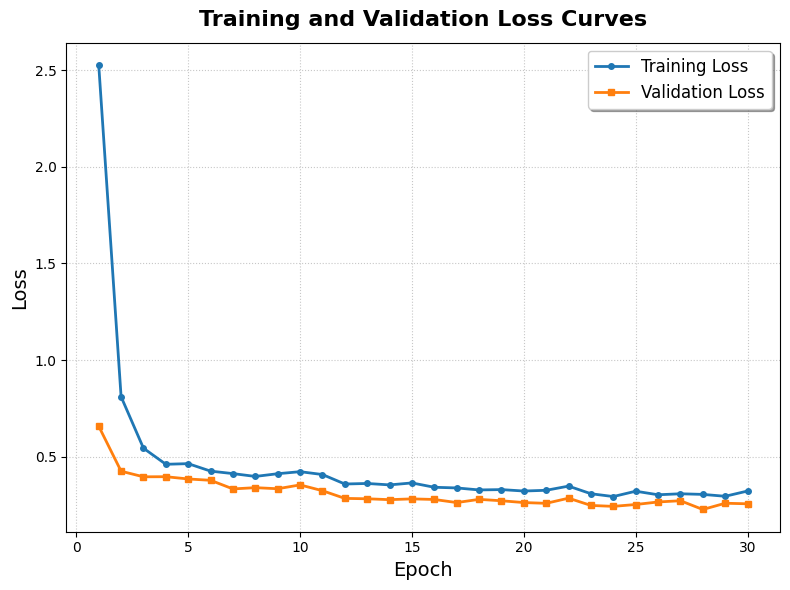

In [56]:
# 绘制训练曲线
plot_curves(radiomics_train_losses, radiomics_val_losses, 
            model_name=radiomics_model_name, epoch=radiomics_epochs, save=True)


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 28.10it/s]


✅ Test Accuracy: 0.5973

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.42      0.31      0.36       131
   malignant       0.66      0.76      0.71       234

    accuracy                           0.60       365
   macro avg       0.54      0.53      0.53       365
weighted avg       0.58      0.60      0.58       365

✅ Saved confusion matrix to ./RadiomicsMLP_30/confusion_matrix.pdf


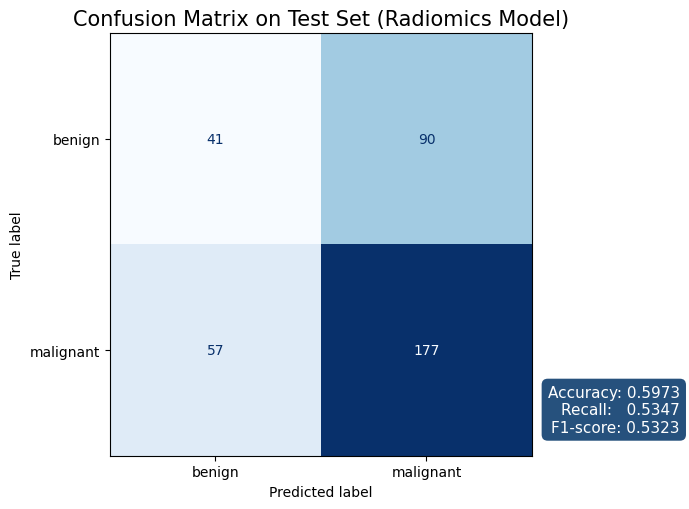

In [57]:
# 在测试集上评估
# 注意：evaluate_on_testset 函数需要适配特征数据，这里我们创建一个简化版本
def evaluate_radiomics_model(model, test_loader, dataset, model_name=None, epoch=None, save=True, save_dir="."):
    """评估影像组学模型"""
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for features, labels in tqdm(test_loader, desc="Evaluating"):
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate metrics
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\n✅ Test Accuracy: {acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title("Confusion Matrix on Test Set (Radiomics Model)", fontsize=15)

    ax.tick_params(axis='both', labelsize=10)

    metrics_text = (
        f"Accuracy: {acc:.4f}\n"
        f"Recall:   {recall:.4f}\n"
        f"F1-score: {f1:.4f}"
    )

    ax.text(
        1.35, 0.05, metrics_text,
        transform=ax.transAxes,
        fontsize=11,
        va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", fc="#003366", ec="none", alpha=0.85),
        color="white",
    )

    plt.tight_layout()

    if save and model_name is not None and epoch is not None:
        save_path = os.path.join(save_dir, f"{model_name}_{epoch}")
        os.makedirs(save_path, exist_ok=True)
        out_path = f"{save_path}/confusion_matrix.pdf"
        plt.savefig(out_path, format="pdf", bbox_inches="tight")
        print(f"✅ Saved confusion matrix to {out_path}")

    plt.show()
    plt.close()

# 评估模型
evaluate_radiomics_model(radiomics_model, test_radiomics_loader, test_radiomics_ds, 
                         model_name=radiomics_model_name, epoch=radiomics_epochs, save=True)


## Pixels + Radiomics Fusion Model Training Pipeline


In [44]:
# ===== 融合模型训练 Pipeline ===== #
fusion_model_name = 'DenseNet121RadiomicsFusion'

# 数据目录和特征缓存路径
data_dir = "./BreaKHis_400X"
train_fusion_cache = "./fusion_features_train.npz"
test_fusion_cache = "./fusion_features_test.npz"

# ===== 统一使用 ImageNet 归一化 ===== #
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

mean_used = IMAGENET_MEAN
std_used = IMAGENET_STD


# ====== ★★★ 核心修复：过滤掉 .DS_Store ★★★ ====== #
def safe_listdir(path):
    return [
        f for f in os.listdir(path)
        if not f.startswith('.') and f.lower() != "ds_store"
    ]

def safe_join_images(path):
    out = []
    for cls in safe_listdir(path):  # 过滤类别目录
        cls_path = os.path.join(path, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in safe_listdir(cls_path):  # 过滤图像文件
            full = os.path.join(cls_path, f)
            if os.path.isfile(full) and f.lower().endswith((".png", ".jpg", ".jpeg")):
                out.append(full)
    return out


# ===== 数据增强 ===== #
train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_used, std=std_used),
])

test_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_used, std=std_used),
])


# ===== ★★ 构造 FusionDataset（加入过滤）★★ #
full_train_fusion_ds = FusionDataset(
    os.path.join(data_dir, "train"),
    transform=train_tfms,
    feature_cache_path=train_fusion_cache,
    safe_mode=True,                  # ★重要：在 FusionDataset 内进行二重过滤
    valid_exts=(".png", ".jpg", ".jpeg")
)

test_fusion_ds = FusionDataset(
    os.path.join(data_dir, "test"),
    transform=test_tfms,
    feature_cache_path=test_fusion_cache,
    safe_mode=True,                  # 同上
    valid_exts=(".png", ".jpg", ".jpeg")
)


# ===== 划分验证集 ===== #
val_ratio = 0.2
val_size = int(len(full_train_fusion_ds) * val_ratio)
train_size = len(full_train_fusion_ds) - val_size
train_fusion_ds, val_fusion_ds = random_split(
    full_train_fusion_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_fusion_loader = DataLoader(train_fusion_ds, batch_size=16, shuffle=True)
val_fusion_loader = DataLoader(val_fusion_ds, batch_size=16)
test_fusion_loader = DataLoader(test_fusion_ds, batch_size=16)


# ===== 创建融合模型 ===== #
fusion_model = ResNet50RadiomicsFusion(
    radiomics_dim=39,
    resnet_feature_dim=256,
    radiomics_reduced_dim=64,
    fusion_dim=128,
    num_classes=2,
    dropout=0.3
)


# ===== 计算类别权重 ===== #
class_counts_fusion = torch.zeros(2)
for _, _, label in train_fusion_ds:
    class_counts_fusion[label] += 1

class_weights_fusion = 1.0 / (class_counts_fusion + 1e-6)
class_weights_fusion = class_weights_fusion / class_weights_fusion.sum() * len(class_weights_fusion)

print(f"\n📊 Fusion Dataset - Class distribution in training set:")
for i, class_name in enumerate(full_train_fusion_ds.classes):
    print(f"  {class_name}: {int(class_counts_fusion[i])} samples")

print(f"\n⚖️  Class weights: {class_weights_fusion.tolist()}")
print(f"📦 Dataset sizes - Train: {len(train_fusion_ds)}, Val: {len(val_fusion_ds)}, Test: {len(test_fusion_ds)}")
print(f"📐 Model architecture:")
print(f"  - ResNet50 feature dim: 256")
print(f"  - Radiomics reduced dim: 64")
print(f"  - Fusion dim: 128")
print(f"  - Final output: 2 classes")


Loading cached radiomics features from ./fusion_features_train.npz
Loaded 1264 cached features
FusionDataset size: 1264, Radiomics feature dimension: 39
Loading cached radiomics features from ./fusion_features_test.npz
Loaded 556 cached features
FusionDataset size: 556, Radiomics feature dimension: 39

📊 Fusion Dataset - Class distribution in training set:
  benign: 336 samples
  malignant: 676 samples

⚖️  Class weights: [1.335968255996704, 0.6640315651893616]
📦 Dataset sizes - Train: 1012, Val: 252, Test: 556
📐 Model architecture:
  - ResNet50 feature dim: 256
  - Radiomics reduced dim: 64
  - Fusion dim: 128
  - Final output: 2 classes


In [45]:
# ===== 训练融合模型 ===== #
fusion_epochs = 30
fusion_train_losses, fusion_val_losses, fusion_train_accs = train_model(
    fusion_model,
    train_fusion_loader,
    val_fusion_loader,
    epochs=fusion_epochs,
    lr=1e-4,
    class_weights=class_weights_fusion,
    weight_decay=1e-4,
    is_fusion=True  # 重要：标记为融合模型
)

Epoch 1/30: 100%|██████████| 64/64 [00:36<00:00,  1.74it/s]


Epoch 1 | Train Loss: 1.4153 | Train Acc: 0.6492 | Val Loss: 0.2586 | Val Acc: 0.9127 | LR: 1.00e-04


Epoch 2/30: 100%|██████████| 64/64 [00:33<00:00,  1.93it/s]


Epoch 2 | Train Loss: 0.7138 | Train Acc: 0.8389 | Val Loss: 0.3448 | Val Acc: 0.9405 | LR: 1.00e-04


Epoch 3/30: 100%|██████████| 64/64 [00:32<00:00,  1.99it/s]


...

Epoch 28 | Train Loss: 0.0199 | Train Acc: 0.9951 | Val Loss: 0.1006 | Val Acc: 0.9881 | LR: 1.00e-07


Epoch 29/30: 100%|██████████| 64/64 [00:31<00:00,  2.02it/s]


Epoch 29 | Train Loss: 0.0105 | Train Acc: 0.9960 | Val Loss: 0.1002 | Val Acc: 0.9921 | LR: 1.00e-07


Epoch 30/30: 100%|██████████| 64/64 [00:31<00:00,  2.02it/s]


Epoch 30 | Train Loss: 0.0180 | Train Acc: 0.9941 | Val Loss: 0.1157 | Val Acc: 0.9881 | LR: 1.00e-08 ⬇️


In [46]:
# ===== 保存融合模型 ===== #
os.makedirs(f"./{fusion_model_name}_{fusion_epochs}", exist_ok=True)
torch.save(fusion_model.state_dict(), f"{fusion_model_name}_{fusion_epochs}/model.pth")
print(f"✅ Fusion model saved to {fusion_model_name}_{fusion_epochs}/model.pth")

✅ Fusion model saved to DenseNet121RadiomicsFusion_30/model.pth


✅ Saved loss curve to ./DenseNet121RadiomicsFusion_30/loss_curves.pdf


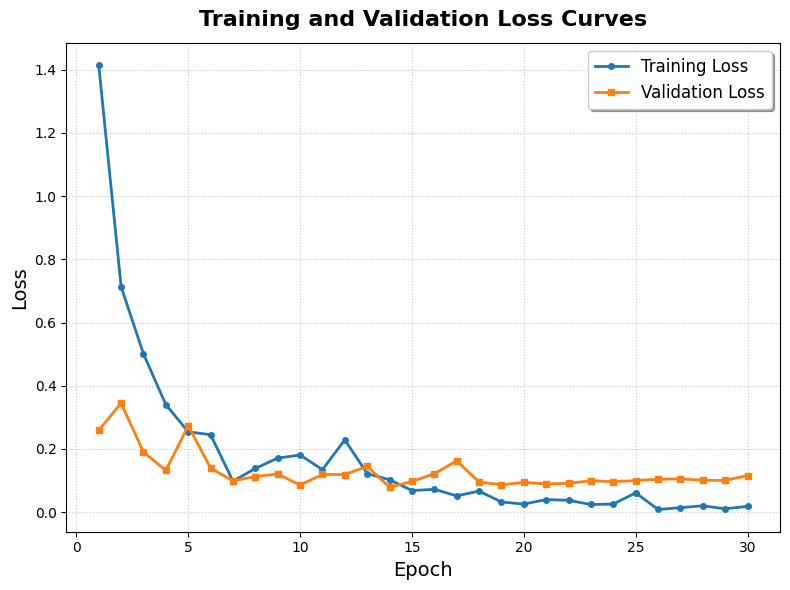

In [47]:
# ===== 绘制训练曲线 ===== #
plot_curves(fusion_train_losses, fusion_val_losses, 
            model_name=fusion_model_name, epoch=fusion_epochs, save=True)


Evaluating: 100%|██████████| 35/35 [00:07<00:00,  4.44it/s]



✅ Test Accuracy: 0.7716

📊 Classification Report:
              precision    recall  f1-score   support

      benign       0.72      0.45      0.55       175
   malignant       0.78      0.92      0.85       381

    accuracy                           0.77       556
   macro avg       0.75      0.68      0.70       556
weighted avg       0.76      0.77      0.75       556

✅ Saved confusion matrix to ./DenseNet121RadiomicsFusion_30/confusion_matrix.pdf


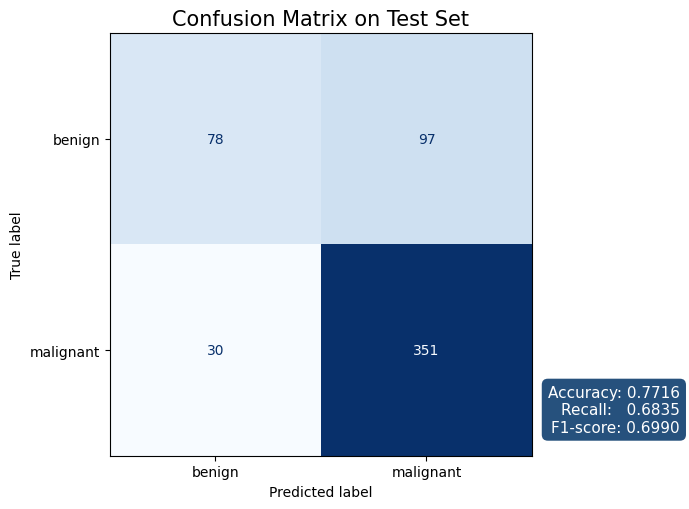

In [48]:
# ===== 在测试集上评估融合模型 ===== #
evaluate_on_testset(
    fusion_model, 
    test_fusion_loader, 
    test_fusion_ds, 
    model_name=fusion_model_name, 
    epoch=fusion_epochs, 
    save=True,
    is_fusion=True  # 重要：标记为融合模型
)